In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd ..

/Users/leonmac/Codes/BO-Set


In [3]:
import numpy as np
import torch
import networkx as nx
import multiprocess
import time
import os
import warnings
import matplotlib.pyplot as plt
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
from ndlib.models.epidemics.SIRModel import SIRModel
from publib import set_style, fix_style
set_style(['article']) 

In [4]:
graph_type = 'ws' # use real-world ['day1', 'day2'] or a 'ws' random network

In [5]:
def graph_relabel(Graph):
    node_list = [i for i in Graph.nodes()]
    mapping = {old_node: new_idx for new_idx, old_node in enumerate(node_list, start=0)}
    return nx.relabel_nodes(Graph, mapping)

In [6]:
# Underlying Network
N=5000 # number of nodes in the underlying network
threshold = 0.5 # threshold for percentage of popupation infection that we are interested in
T=100 # number of iterations in each SIR run
n_samples = 1000 # number of MC samples
g = nx.generators.random_graphs.watts_strogatz_graph(n=N, k=10, p=0.1, seed=0) # an example WS network
G1 = nx.read_gexf('problems/primary_school_contact_network_day1.gexf_')
G2 = nx.read_gexf('problems/primary_school_contact_network_day2.gexf_')
G1 = graph_relabel(G1) # real-world contact network in a French primary school day 1
G2 = graph_relabel(G2) # real-world contact network in a French primary school day 2

# Model Configuration
cfg = mc.Configuration()
#cfg.add_model_parameter('beta', 0.001)
#cfg.add_model_parameter('gamma', 0.01)
cfg.add_model_parameter("fraction_infected", 0.1)
ComboNode = torch.tensor([10,11,12,13,14,15]).tolist()

In [7]:
if graph_type == 'day1':
    graph = G1
    N=G1.number_of_nodes()
    pos = nx.kamada_kawai_layout(G1)
elif graph_type == 'day2':
    graph = G2
    N=G2.number_of_nodes()
    pos = nx.kamada_kawai_layout(G2)
elif graph_type == 'ws':
    graph = g

In [8]:
def get_initial_status(Graph, ComboNode): # set the initial state to the chosen ComboNode
    node_list = [i for i in Graph.nodes()]
    mapping = {node: 1 if node in ComboNode else 0 for node in node_list}
    return mapping
def One_IC_Run(Graph, cfg, ComboNode, T, idx):
    model = ep.IndependentCascadesModel(Graph)
    # Setting the edge parameters
    threshold = 0.2
    for e in g.edges():
        cfg.add_edge_configuration("threshold", e, threshold)
    model.set_initial_status(cfg)
    model.status = get_initial_status(Graph, ComboNode)
    iterations = model.iteration_bunch(T)
    return iterations
def SIR_parallel(idx):
    return One_IC_Run(graph,cfg,ComboNode,T,idx)
start_time = time.time()
# Simulation execution
with multiprocess.Pool() as pool:
    results = pool.map(SIR_parallel, list(range(n_samples)))
end_time = time.time()
print(f"time cost:{(end_time - start_time):.4f}s")

time cost:14.0228s


/Users/leonmac/anaconda3/lib/python3.11/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/Users/leonmac/anaconda3/lib/python3.11/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/Users/leonmac/anaconda3/lib/python3.11/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/Users/leonmac/anaconda3/lib/python3.11/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/Users/leonmac/anaconda3/lib/python3

In [9]:
influenced_count = np.array([results[j][-1]['node_count'][2] for j in range(n_samples)])
function_value = np.round(influenced_count.mean(),1)

In [10]:
function_value

3381.4

In [11]:
S = [results[0][i]['node_count'][0] for i in range(T)]
I = [results[0][i]['node_count'][1] for i in range(T)]
R = [results[0][i]['node_count'][2] for i in range(T)]
t = range(T)
infection_time = sum(np.array(S)>(N*(1-threshold)))

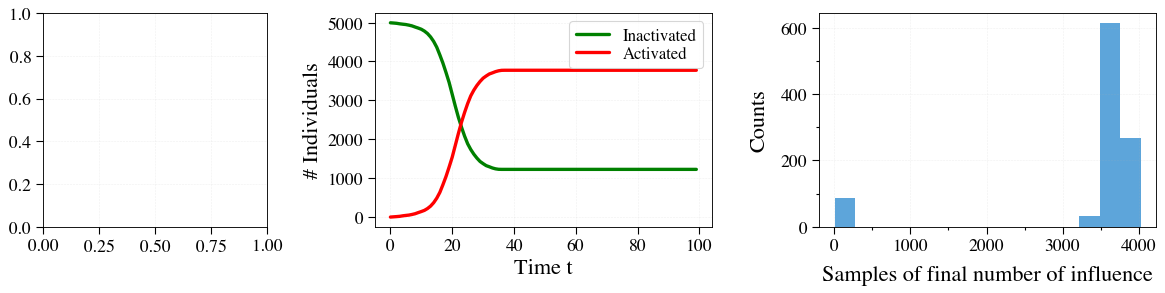

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={'width_ratios': [1, 1.5, 1.5]})

if graph_type in ["day1","day2"]:
    node_size = 100
    nx.draw_networkx(graph, pos, with_labels=False, node_size=node_size, width=1, alpha=0.99, 
                     ax=axs[0], node_color = 'black', edge_color='gray')
    nx.draw_networkx_nodes(G1, pos, node_size=node_size*0.9, 
                           ax=axs[0], node_color='steelblue')
    axs[0].set_axis_off()

axs[1].plot(t, S, 'green', lw=3, label='Inactivated')
#axs[1].plot(t, I, 'red', lw=3, label='Current Act.')
axs[1].plot(t, R, 'red', lw=3, label='Activated')
#axs[1].axvline(x=infection_time, color='darkviolet', linestyle='--', label=f'{int(threshold*100)}% Infection')
#axs[1].text(infection_time + 10, N*0.8, f't*={infection_time}', verticalalignment='bottom')
axs[1].set_xlabel('Time t')
axs[1].set_ylabel('# Individuals')
axs[1].legend(frameon=True, fontsize=15)

axs[2].hist(influenced_count, bins=15)
axs[2].set_xlabel('Samples of final number of influence')
axs[2].set_ylabel('Counts')
#axs[2].axvline(x=function_value, color='red', linestyle='--')
#axs[2].text(function_value + 10, 20*0.8, f'E[t*]={function_value}', verticalalignment='bottom')

fix_style('article')

save_dir = './experiment_figs/Supporting'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
plt.savefig(f"{save_dir}/IC_deom.pdf", bbox_inches='tight')
plt.savefig(f"{save_dir}/IC_deom.png", bbox_inches='tight')
plt.savefig(f"{save_dir}/IC_deom.jpg", bbox_inches='tight')

plt.show()